# Case FarmaSaúde

##Contexto e Problema

A FarmaSaúde atua no farmacêutico, veterinário e de bem-estar há mais de 10 anos, com unidades físicas distribuídas no Nordeste do Brasil e, mais recentemente, com vendas online para todo o país.

O mercado farmacêutico demonstrou grande resiliência e segue em expansão. Muitas pessoas mudaram seus hábitos de consumo durante o período de isolamento, passando a priorizar o autocuidado, a prevenção e a manutenção da saúde de forma mais rigorosa. O CEO da FarmaSaúde tem uma grande preocupação sobre como a empresa irá capturar e fidelizar essa fatia crescente do mercado.

Desde o início do ano passado, a FarmaSaúde iniciou um plano para acelerar a transformação digital da empresa e a estruturação dos dados dos clientes para melhorar sua jornada de compra. Com as análises realizadas, decidiram lançar um programa de fidelidade que permite identificar as compras dos clientes nas lojas físicas, canal onde possuem o maior volume de vendas e interação direta.

O CEO é analítico e orientado a resultados, participa ativamente das transformações da empresa e orienta o time nos planejamentos estratégicos. Ele proporciona um ambiente com total autonomia para o time realizar as mudanças necessárias e acompanha mensalmente, em comitê, os resultados das iniciativas. As expectativas sobre o retorno dessas transformações são altas.

O CEO me enviou algumas dúvidas estratégicas, pedindo minha ajuda para respondê-las:

## Questões Estratégicas
1. Previsão de Demanda: Queremos realizar o planejamento da venda de medicamentos para Adultos para os próximos seis meses. Qual a previsão de venda diária para essa categoria em nossas unidades?

2. Segmentação de Clientes: Sabemos que nem todos os clientes possuem o mesmo perfil; alguns geram um LTV (Lifetime Value) muito superior a outros. Podemos segregar os clientes em grupos específicos? Há algum segmento significativamente mais rentável?

3. Análise de Churn e Retenção: Uma das prioridades para o próximo ano é aumentar a retenção. Na companhia, consideramos o cliente inativo quando ele não realiza transações por mais de 90 dias. Qual seria o grupo alvo para ações de retenção? Ou seja: qual perfil de cliente apresenta o maior risco de churn?

4. Recomendação de Produtos: Com base no histórico de compras e no comportamento de navegação, quais outros produtos (como vitaminas, dermocosméticos ou itens de higiene) podemos oferecer de forma personalizada para cada cliente?

---

O projeto vai ser iniciado pela exploração dos dados cedidos pelo CEO, para então avançar para as perguntas estratégicas que ele me fez.

# Leitura e Interpretação dos Dados

In [ ]:
#criar drive no google
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import datetime as  dt

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
path = "/content/drive/MyDrive/Colab Notebooks/Projeto Case Data Science"
sns.set_style("darkgrid")

In [ ]:
# Tabela de clientes

clientes_df  = pd.read_csv(path+"/cliente.csv")
display(clientes_df)
clientes_df.info()

,ID_CLIENTE,SEXO,DATA_NASCIMENTO,PRIMEIRA_COMPRA
0,0,,1900/01/01,2017/03/06
1,1,,1900/01/01,2017/03/06
2,2,,1900/01/01,2017/03/06
3,3,,1900/01/01,2017/02/18
4,4,,1900/01/01,2017/01/16
...,...,...,...,...
105919,105919,F,1977/09/11,2021/10/16
105920,105920,,1900/01/01,1900/01/01
105921,105921,,1900/01/01,1900/01/01
105922,105922,F,1985/05/15,2021/10/16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105924 entries, 0 to 105923
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ID_CLIENTE       105924 non-null  int64 
 1   SEXO             105924 non-null  object
 2   DATA_NASCIMENTO  105924 non-null  object
 3   PRIMEIRA_COMPRA  105924 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.2+ MB


In [ ]:
# Tabela de produtos

produtos_df  = pd.read_csv(path+"/produto.csv")
display(produtos_df)
produtos_df.info()

,ID_PRODUTO,UNIDADE,NIVEL 1,NIVEL 2,NIVEL 3,NIVEL 4
0,0,UN,ADULTO,NUTRICAO E DIETETICOS,BARRAS E SNACKS NUTRITIVOS,BISCOITOS E SNACKS DIETETICOS
1,2,UN,ADULTO,NUTRICAO E DIETETICOS,BARRAS E SNACKS NUTRITIVOS,BISCOITOS E SNACKS DIETETICOS
2,3,UN,NaN,NaN,NaN,NaN
3,4,UN,ADULTO,FARMACIA,DORES E INFECCOES,ANTIBIOTICOS
4,4,UN,ADULTO,FARMACIA,DORES E INFECCOES,ANTIBIOTICOS
...,...,...,...,...,...,...
38298,38303,UN,NaN,NaN,NaN,NaN
38299,38304,UN,NaN,NaN,NaN,NaN
38300,38305,UN,NaN,NaN,NaN,NaN
38301,38306,UN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID_PRODUTO  38303 non-null  int64 
 1   UNIDADE     38303 non-null  object
 2   NIVEL 1     25734 non-null  object
 3   NIVEL 2     25734 non-null  object
 4   NIVEL 3     25473 non-null  object
 5   NIVEL 4     23190 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.8+ MB


In [ ]:
# Tabela de vendas

vendas_df  = pd.read_csv(path+"/venda.csv",decimal='.',thousands=',')
display(vendas_df)
vendas_df.info()

,ID_VENDA,DATA_VENDA,ID_CLIENTE,ID_PRODUTO,QUANTIDADE,CATEGORIA_VENDA,FILIAL
0,0,2021/02/10,45659.0,17631,1.0,E-COMMERCE,101
1,0,2021/02/10,45659.0,34575,1.0,E-COMMERCE,101
2,1,2021/02/12,70766.0,2240,1.0,E-COMMERCE,101
3,2,2021/02/12,42579.0,17707,1.0,E-COMMERCE,101
4,2,2021/02/12,42579.0,8952,1.0,E-COMMERCE,101
...,...,...,...,...,...,...,...
1859578,854530,2021/10/23,NaN,36642,10.0,Loja,113
1859579,854530,2021/10/23,NaN,7332,10.0,Loja,113
1859580,854530,2021/10/23,NaN,7333,10.0,Loja,113
1859581,854531,2021/10/23,106865.0,7528,1.0,Loja,113


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1859583 entries, 0 to 1859582
Data columns (total 7 columns):
 #   Column           Dtype  
---  ------           -----  
 0   ID_VENDA         int64  
 1   DATA_VENDA       object 
 2   ID_CLIENTE       float64
 3   ID_PRODUTO       int64  
 4   QUANTIDADE       float64
 5   CATEGORIA_VENDA  object 
 6   FILIAL           int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 99.3+ MB


In [ ]:
# Conversão para dados de Data

clientes_df['DATA_NASCIMENTO'] = pd.to_datetime(clientes_df['DATA_NASCIMENTO'],errors='ignore')
clientes_df['PRIMEIRA_COMPRA'] = pd.to_datetime(clientes_df['PRIMEIRA_COMPRA'],errors='ignore')

vendas_df['DATA_VENDA'] = pd.to_datetime(vendas_df['DATA_VENDA'],format='%Y/%m/%d',errors='ignore')

/tmp/ipykernel_1188/1612202919.py:3: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead

/tmp/ipykernel_1188/1612202919.py:4: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead

/tmp/ipykernel_1188/1612202919.py:6: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



In [ ]:
# Remoção de dados vazios por nulos

clientes_df.replace(r'^\s*$', np.nan, regex=True,inplace=True)
produtos_df.replace(r'^\s*$', np.nan, regex=True,inplace=True)
vendas_df.replace(r'^\s*$', np.nan, regex=True,inplace=True)

display(clientes_df.info())
display(produtos_df.info())
display(vendas_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105924 entries, 0 to 105923
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ID_CLIENTE       105924 non-null  int64         
 1   SEXO             46523 non-null   object        
 2   DATA_NASCIMENTO  105924 non-null  object        
 3   PRIMEIRA_COMPRA  105924 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID_PRODUTO  38303 non-null  int64 
 1   UNIDADE     38303 non-null  object
 2   NIVEL 1     25734 non-null  object
 3   NIVEL 2     25734 non-null  object
 4   NIVEL 3     25473 non-null  object
 5   NIVEL 4     23190 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.8+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1859583 entries, 0 to 1859582
Data columns (total 7 columns):
 #   Column           Dtype         
---  ------           -----         
 0   ID_VENDA         int64         
 1   DATA_VENDA       datetime64[ns]
 2   ID_CLIENTE       float64       
 3   ID_PRODUTO       int64         
 4   QUANTIDADE       float64       
 5   CATEGORIA_VENDA  object        
 6   FILIAL           int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 99.3+ MB


None

In [ ]:
# Retirar espaço vazio nas strings dos niveis

def delete_space(s):
  try:
    return s.split(" ")[0]
  except:
    return np.nan

produtos_df["NIVEL 1"] = produtos_df["NIVEL 1"].apply(lambda s: delete_space(s))



In [ ]:
produtos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID_PRODUTO  38303 non-null  int64 
 1   UNIDADE     38303 non-null  object
 2   NIVEL 1     25734 non-null  object
 3   NIVEL 2     25734 non-null  object
 4   NIVEL 3     25473 non-null  object
 5   NIVEL 4     23190 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.8+ MB


In [ ]:
# Distribuição percentual de cada nivel 2 nos niveis 1
n1_n2 = (produtos_df.groupby("NIVEL 1")['NIVEL 2'].value_counts()/produtos_df.groupby("NIVEL 1")['NIVEL 2'].count()).reset_index(0)

# 'NIVEL 2' is currently the index, not a column. Reset index to convert it to a column.
n1_n2.reset_index(inplace=True)

# The percentage values are in the column named '0'. Rename it to 'value'.
n1_n2.rename(columns={0: 'value'}, inplace=True)

# Round the values as intended.
n1_n2['value'] = n1_n2['value'].round(3)

fig = px.bar(n1_n2, x = 'NIVEL 1', y = 'value', color='NIVEL 2',labels={"value":"Porcentagem"},template="seaborn")
fig.update_layout(title={'text':'Composição dos produtos pela categoria principal','x':0.25})
fig.show()

Insights:
- Podemos ver que apesar da FarmaSaúde ser principalemente uma farmácia, suas vendas estão bem distribuidas nas suas outras categorias diversas (veterinária e bem-estar)

---
# 1. Previsão de Demanda

In [ ]:
historico_total = vendas_df[['DATA_VENDA','QUANTIDADE']].groupby('DATA_VENDA').sum()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=historico_total.index, y=historico_total['QUANTIDADE'],
                  mode='lines',
                  name='Real'))

fig.show()

Insights sobre o histórico de vendas:
- Ciclos Sazonais Claros - deve-se realizar uma análise como (autocorrelação parcial) para identificá-los
- Histórico de dados pequeno - cerca de somente 1 ano de histórico de dados
- Pode-se observar nitidamente a presença de um outlier no mês de outubro de 2021 e deve-se ficar atento para verificar se esse outlier está ou não relacionado aos produtos para Adultos

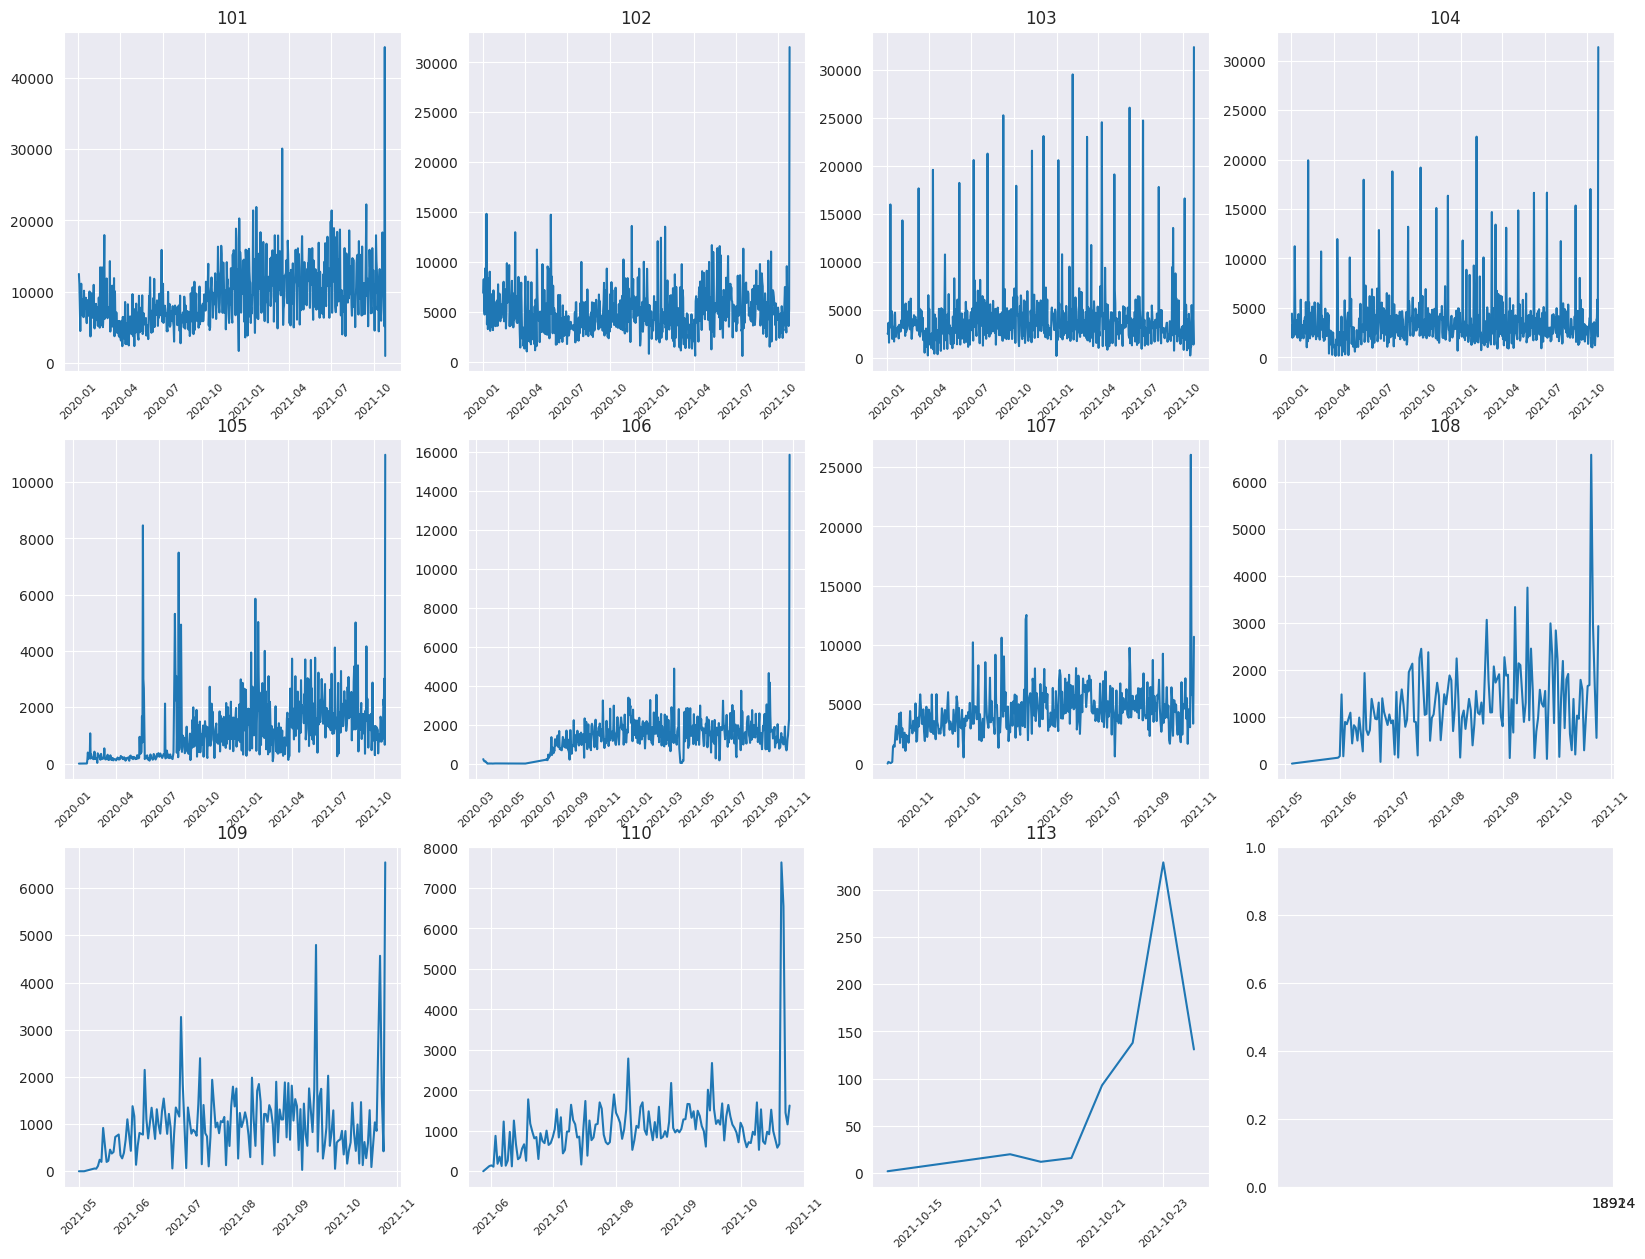

In [ ]:
#Analise da demanda por filial da FarmaSaúde

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

counter_x = 0
counter_y = 0
for filial in vendas_df.FILIAL.unique():
  df_plot_vendas = vendas_df[vendas_df.FILIAL== filial][['DATA_VENDA','QUANTIDADE']].groupby('DATA_VENDA').sum()
  axes[counter_x,counter_y].plot(df_plot_vendas.index, df_plot_vendas['QUANTIDADE'].values)
  plt.xticks([df_plot_vendas.index.min(),df_plot_vendas.index.max()])
  axes[counter_x,counter_y].set_title(filial)
  axes[counter_x,counter_y].tick_params(axis="x", labelsize=8, rotation =45)
  counter_y += 1
  if counter_y%4 == 0:
    counter_y = 0
    counter_x += 1

- Comportamento diferente da demanda entre as diferentes filiais, desde horizonte histórico até aspecto da série temporal
- Indica que a melhor estratégia é prever a demanda de maneira agregada

<Axes: ylabel='FILIAL'>

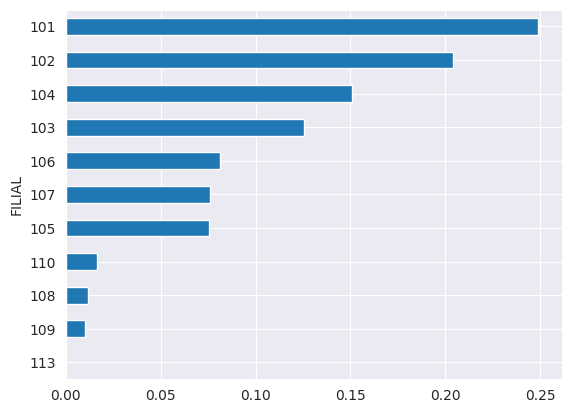

In [ ]:
vendas_df['FILIAL'].value_counts(normalize=True).sort_values(ascending=True).plot(kind='barh')

In [ ]:
diario_total = historico_total[['QUANTIDADE']].asfreq('D')
diario_total.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 664 entries, 2020-01-02 to 2021-10-26
Freq: D
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   QUANTIDADE  663 non-null    float64
dtypes: float64(1)
memory usage: 10.4 KB


In [ ]:
diario_total[diario_total.QUANTIDADE.isna()]

,QUANTIDADE
DATA_VENDA,
2020-02-25,NaN


## Vendas de produtos para Adultos

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.1 MB/s eta 0:00:00


In [ ]:
!pip install prophet

In [ ]:
!pip install statsmodels -U

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.signal import periodogram
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import datetime as dt
from prophet import Prophet
from pmdarima import auto_arima
from pmdarima.preprocessing import FourierFeaturizer
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

In [ ]:
df_vendas_produto = vendas_df.merge(produtos_df, on = 'ID_PRODUTO', how = 'left')
df_vendas_produto

In [ ]:
df_vendas_adultos = df_vendas_produto[df_vendas_produto['NIVEL 1']== 'ADULTO']
df_vendas_adultos

,ID_VENDA,DATA_VENDA,ID_CLIENTE,ID_PRODUTO,QUANTIDADE,CATEGORIA_VENDA,FILIAL,UNIDADE,NIVEL 1,NIVEL 2,NIVEL 3,NIVEL 4
1,0,2021-02-10,45659.0,34575,1.0,E-COMMERCE,101,UN,ADULTO,NUTRICAO E DIETETICOS,BARRAS E SNACKS NUTRITIVOS,BISCOITOS E SNACKS DIETETICOS
3,2,2021-02-12,42579.0,17707,1.0,E-COMMERCE,101,UN,ADULTO,FARMACIA,VITAMINAS E SUPLEMENTOS,VITAMINAS E SUPLEMENTOS
4,2,2021-02-12,42579.0,17707,1.0,E-COMMERCE,101,UN,ADULTO,FARMACIA,VITAMINAS E SUPLEMENTOS,VITAMINAS E SUPLEMENTOS
5,2,2021-02-12,42579.0,17707,1.0,E-COMMERCE,101,UN,ADULTO,FARMACIA,VITAMINAS E SUPLEMENTOS,VITAMINAS E SUPLEMENTOS
6,2,2021-02-12,42579.0,17707,1.0,E-COMMERCE,101,UN,ADULTO,FARMACIA,VITAMINAS E SUPLEMENTOS,VITAMINAS E SUPLEMENTOS
...,...,...,...,...,...,...,...,...,...,...,...,...
3924138,854528,2021-10-24,106864.0,31589,1.0,Loja,113,UN,ADULTO,PERFUMARIA E COSMETICOS,HIGIENE E LIMPEZA,COLETORES E RECIPIENTES
3924139,854528,2021-10-24,106864.0,31589,1.0,Loja,113,UN,ADULTO,PERFUMARIA E COSMETICOS,HIGIENE E LIMPEZA,COLETORES E RECIPIENTES
3924140,854528,2021-10-24,106864.0,31589,1.0,Loja,113,UN,ADULTO,PERFUMARIA E COSMETICOS,HIGIENE E LIMPEZA,COLETORES E RECIPIENTES
3924141,854528,2021-10-24,106864.0,31589,1.0,Loja,113,UN,ADULTO,PERFUMARIA E COSMETICOS,HIGIENE E LIMPEZA,COLETORES E RECIPIENTES


In [ ]:
df_vendas_adultos.describe()

,ID_VENDA,DATA_VENDA,ID_CLIENTE,ID_PRODUTO,QUANTIDADE,FILIAL
count,2.508498e+06,2508498,1.215745e+06,2.508498e+06,2.508498e+06,2.508498e+06
mean,4.298662e+05,2020-12-27 21:44:26.338501632,4.882940e+04,1.333122e+04,1.102481e+00,1.033111e+02
min,0.000000e+00,2020-01-02 00:00:00,7.000000e+00,0.000000e+00,1.000000e+00,1.010000e+02
25%,2.122175e+05,2020-08-02 00:00:00,2.912200e+04,4.080000e+03,1.000000e+00,1.010000e+02
50%,4.214620e+05,2021-01-09 00:00:00,4.840000e+04,1.012100e+04,1.000000e+00,1.030000e+02
75%,6.350050e+05,2021-06-05 00:00:00,6.804000e+04,1.950900e+04,1.000000e+00,1.050000e+02
max,8.545310e+05,2021-10-25 00:00:00,1.068650e+05,3.804100e+04,8.400000e+01,1.130000e+02
std,2.421207e+05,NaN,2.625485e+04,1.050529e+04,5.420647e-01,2.208012e+00


<Axes: ylabel='CATEGORIA_VENDA'>

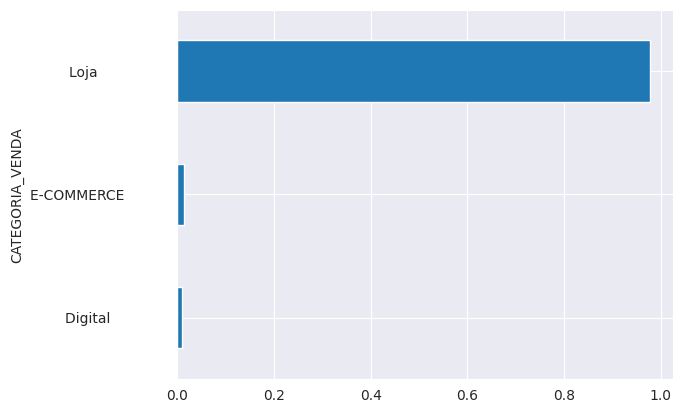

In [ ]:
df_vendas_adultos['CATEGORIA_VENDA'].value_counts(normalize=True).sort_values(ascending=True).plot(kind='barh')

<Axes: ylabel='FILIAL'>

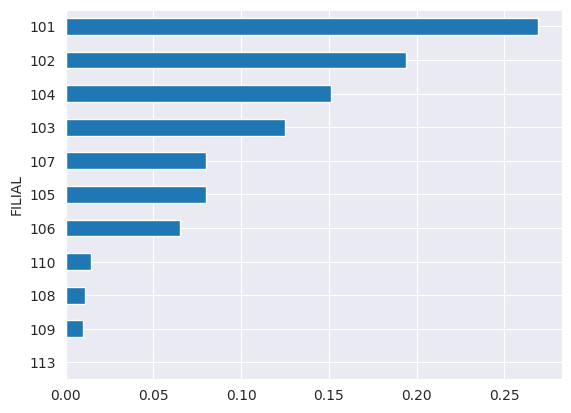

In [ ]:
df_vendas_adultos['FILIAL'].value_counts(normalize=True).sort_values(ascending=True).plot(kind='barh')

In [ ]:
historico_adultos= df_vendas_adultos[['DATA_VENDA','QUANTIDADE']].groupby('DATA_VENDA').sum()
#

fig=go.Figure()
fig.add_trace(go.Scatter(x=historico_adultos.index, y= historico_adultos['QUANTIDADE'], mode='lines', name='Real'))

fig.show()
#

- Não há nenhum outlier nas vendas de produtos de adultos
- Além dos ciclos sazonais, podemos observar uma tendência (em escala semanal e anual, possivelmente relacionado ao fim de ano)

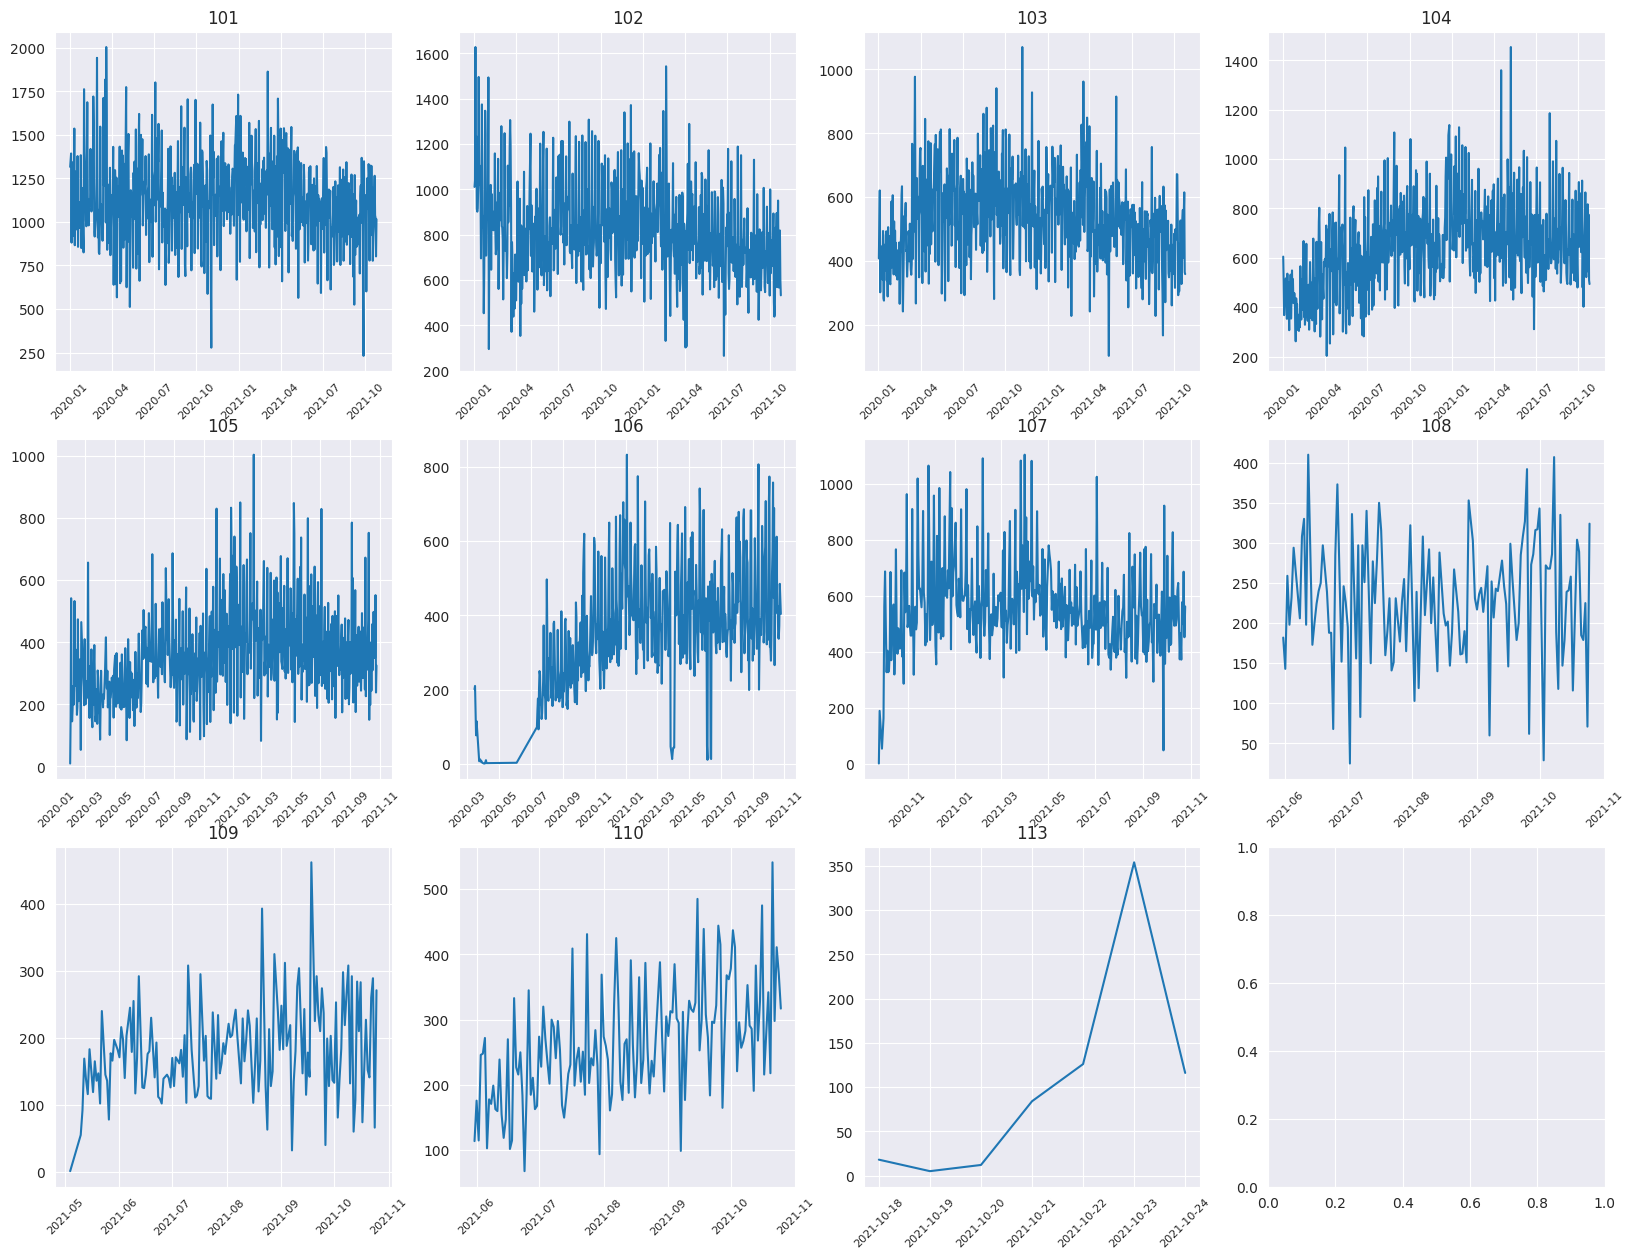

In [ ]:
fig, axes = plt.subplots(3,4, figsize=(20,15))

counter_x=0
counter_y=0
for filial in df_vendas_adultos.FILIAL.unique():
  df_plot_vendas = df_vendas_adultos[df_vendas_adultos.FILIAL== filial][['DATA_VENDA','QUANTIDADE']].groupby('DATA_VENDA').sum()
  axes[counter_x,counter_y].plot(df_plot_vendas.index, df_plot_vendas['QUANTIDADE'].values)
  axes[counter_x,counter_y].set_title(filial)
  axes[counter_x,counter_y].tick_params(axis="x", labelsize=8, rotation =45)
  counter_y += 1
  if counter_y%4 == 0:
    counter_y = 0
    counter_x += 1

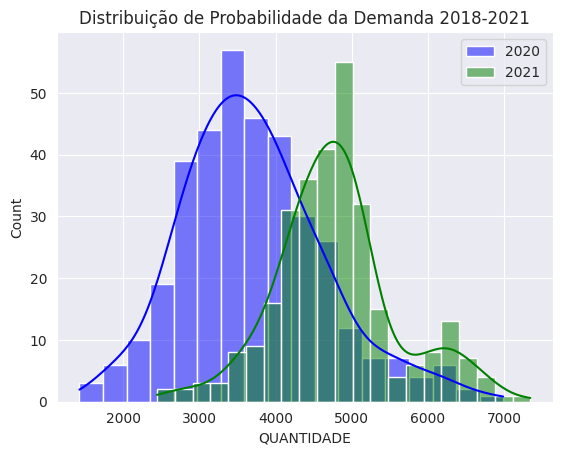

In [ ]:
ax = sns.histplot(
    historico_adultos.loc["2020-01-01":"2021-01-01"]["QUANTIDADE"], label="2020", color='b',kde=True,
)

sns.histplot(
    historico_adultos.loc["2021-01-01":"2021-12-01"]["QUANTIDADE"],
    label="2021",
    color='g',
    ax=ax,kde=True,
)
ax.legend()
ax.set_title("Distribuição de Probabilidade da Demanda 2018-2021");

## Análise dos ciclos sazonais
Para a análise dos ciclos sazonais diversos estratégias podem ser utilizadas. Aqui são realizadas:

- Autocorrelograma parcial
- Periodograma - decomposição em séries de Fourier e análise de cada um dos coeficientes
- Decomposição de série temporal

In [ ]:
plot_pacf(historico_adultos, lags = 40)
plt.show()

**Autocorrelação Parcial(PACF):** Mede a correlação de uma série com ela mesma em diferentes defasagens (lags), removendo o efeito dos lags intermediários.

- Lag 0 → sempre 1.0, pois a série é perfeitamente correlacionada consigo mesma
- Lags 1 a 4 → correlações positivas e significativas (~0.35, 0.25, 0.20, 0.10) — indicam que os valores recentes influenciam diretamente o valor atual.
- Lag 7/8 → pico em ~0.68, bastante relevante — sugere um padrão semanal nos seus dados
- Lag 14/15 → outro pico menor (~0.35) — reforça o padrão semanal (2 semanas)
Demais lags → dentro da banda azul (intervalo de confiança de 95%) = estatisticamente não significativos

In [ ]:
def plot_periodogram(ts, detrend='linear', ax=None):
    fs = 365.25 # Corrected: pd.Timedelta('1Y') is ambiguous. Using average days in a year for daily data.
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

<Axes: title={'center': 'Periodogram'}, ylabel='Variance'>

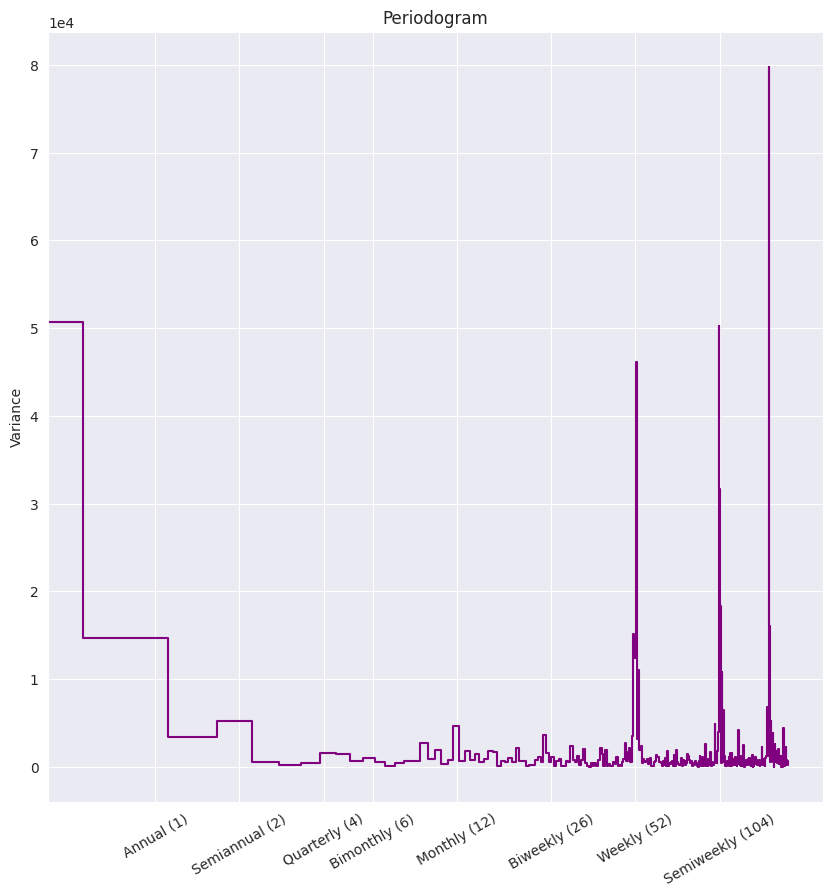

In [ ]:
plot_periodogram(historico_adultos.QUANTIDADE)

**Periodograma:** mostra quanta "energia" (variância) cada frequência contribui para a série temporal. É como decompor a série em ondas e ver quais têm mais força. Podemos ver uma forte recorrencia anual, bi semanal (lag 14 do PACF), semanal (lag 7 do PACF) e a recorrencia mais forte é semisemanal (a cada 3 ou 4 dias)

In [ ]:
adultos_diario= historico_adultos[['QUANTIDADE']].asfreq('D')
adultos_diario.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 663 entries, 2020-01-02 to 2021-10-25
Freq: D
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   QUANTIDADE  659 non-null    float64
dtypes: float64(1)
memory usage: 10.4 KB


In [ ]:
adultos_diario[adultos_diario.QUANTIDADE.isna()]

,QUANTIDADE
DATA_VENDA,
2020-02-25,NaN
2020-05-01,NaN
2020-12-25,NaN
2021-01-01,NaN


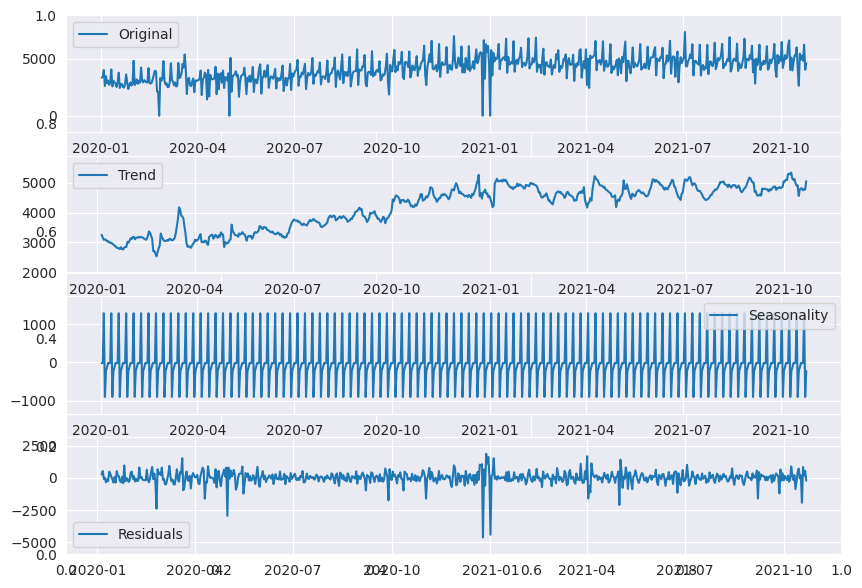

In [ ]:
adultos_diario.fillna(0, inplace = True)
decomposition = seasonal_decompose(adultos_diario.QUANTIDADE)
# define os componentes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# plots
plt.subplots(figsize=(10, 7))
plt.subplot(411)
plt.plot(adultos_diario, label='Original')
plt.legend(loc='best')
plt.margins(y=0.2)

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.margins(y=0.2)

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.margins(y=0.2)

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.margins(y=0.2)

## Feature Engineering

Criação de features temporais, ligadas as datas.

In [ ]:
def criaFeaturesTemporais(df):
    df = df.copy()
    df["Year"]      = df.index.year
    df["Month"]     = df.index.month
    df["Day"]       = df.index.day
    df["WeekDay"]   = df.index.weekday
    df["Quarter"]   = df.index.quarter
    df["DayOfYear"] = df.index.dayofyear
    df["WeekOfYear"] = df.index.isocalendar().week.astype(int)  # substituto do weekofyear
    return df

historico_adultos_temp = criaFeaturesTemporais(historico_adultos)

/tmp/ipykernel_1188/1372480768.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



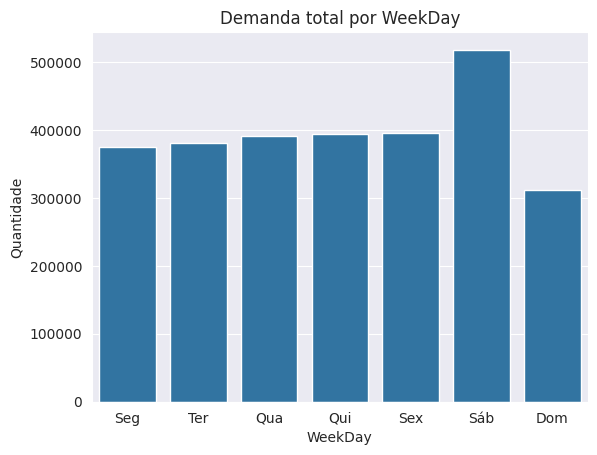

/tmp/ipykernel_1188/1372480768.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



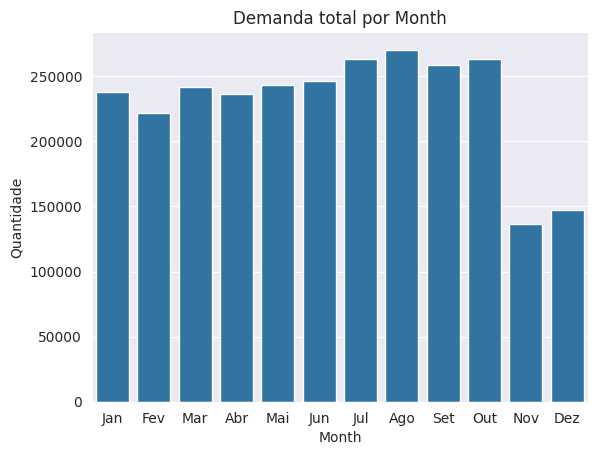

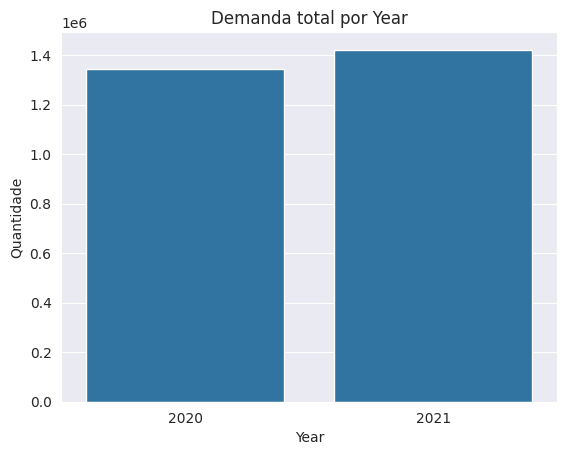

In [ ]:
labels = {
    "WeekDay": ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"],
    "Month":   ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"],
    "Year":    None  # mantém os valores numéricos
}

for col in ["WeekDay", "Month", "Year"]:
    df_plot_vendas = historico_adultos_temp[[col, 'QUANTIDADE']].groupby(col).sum()
    ax = sns.barplot(x=df_plot_vendas.index, y=df_plot_vendas['QUANTIDADE'].values)
    if labels[col]:
        ax.set_xticklabels(labels[col])
    ax.set_title(f'Demanda total por {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Quantidade')
    plt.show()

A análise a partir das features temporais permite identificar:

- Uma sazonalidade semanal, já confirmada pelo autocorrelograma, com um claro número de vendas maior no sabádo (como se trata de loja física, se justifica, sendo um dia em que grande parte dos clientes deve ter disponibilidade para ir comprar na loja) e um número menor de vendas no domingo (onde pode-se imaginar que as lojas fecham mais cedo do que dias normais)

- Apesar do gráfico de análise mes a mes parecer indicar que existe uma menor quantidade de vendas nos últimos meses do ano deve-se atentar ao fato que os meses de novembro e dezembro de 2021 não se encontram na base hisórica, o que justificaria o comportamento observado.

In [ ]:
def criaFeaturesCorrelatas(df):
  df = df.copy()
  #Features auto correlacionadas
  df['lag_1'] = df['QUANTIDADE'].shift(1, freq = 'D')
  df['lag_7'] = df['QUANTIDADE'].shift(7, freq = 'D')
  df['lag_14'] = df['QUANTIDADE'].shift(14, freq = 'D')
  df['lag_21'] = df['QUANTIDADE'].shift(21, freq = 'D')
  df['lag_28'] = df['QUANTIDADE'].shift(28, freq = 'D')
  df['lag_56'] = df['QUANTIDADE'].shift(56, freq = 'D')
  df['rolling_mean_7'] = df['lag_1'].rolling(window=7).mean()
  df['rolling_mean_14'] = df['lag_1'].rolling(window=14).mean()
  df['rolling_mean_21'] = df['lag_1'].rolling(window=21).mean()
  df['rolling_mean_28'] = df['lag_1'].rolling(window=28).mean()
  df['rolling_mean_56'] = df['lag_1'].rolling(window=56).mean()
  return df


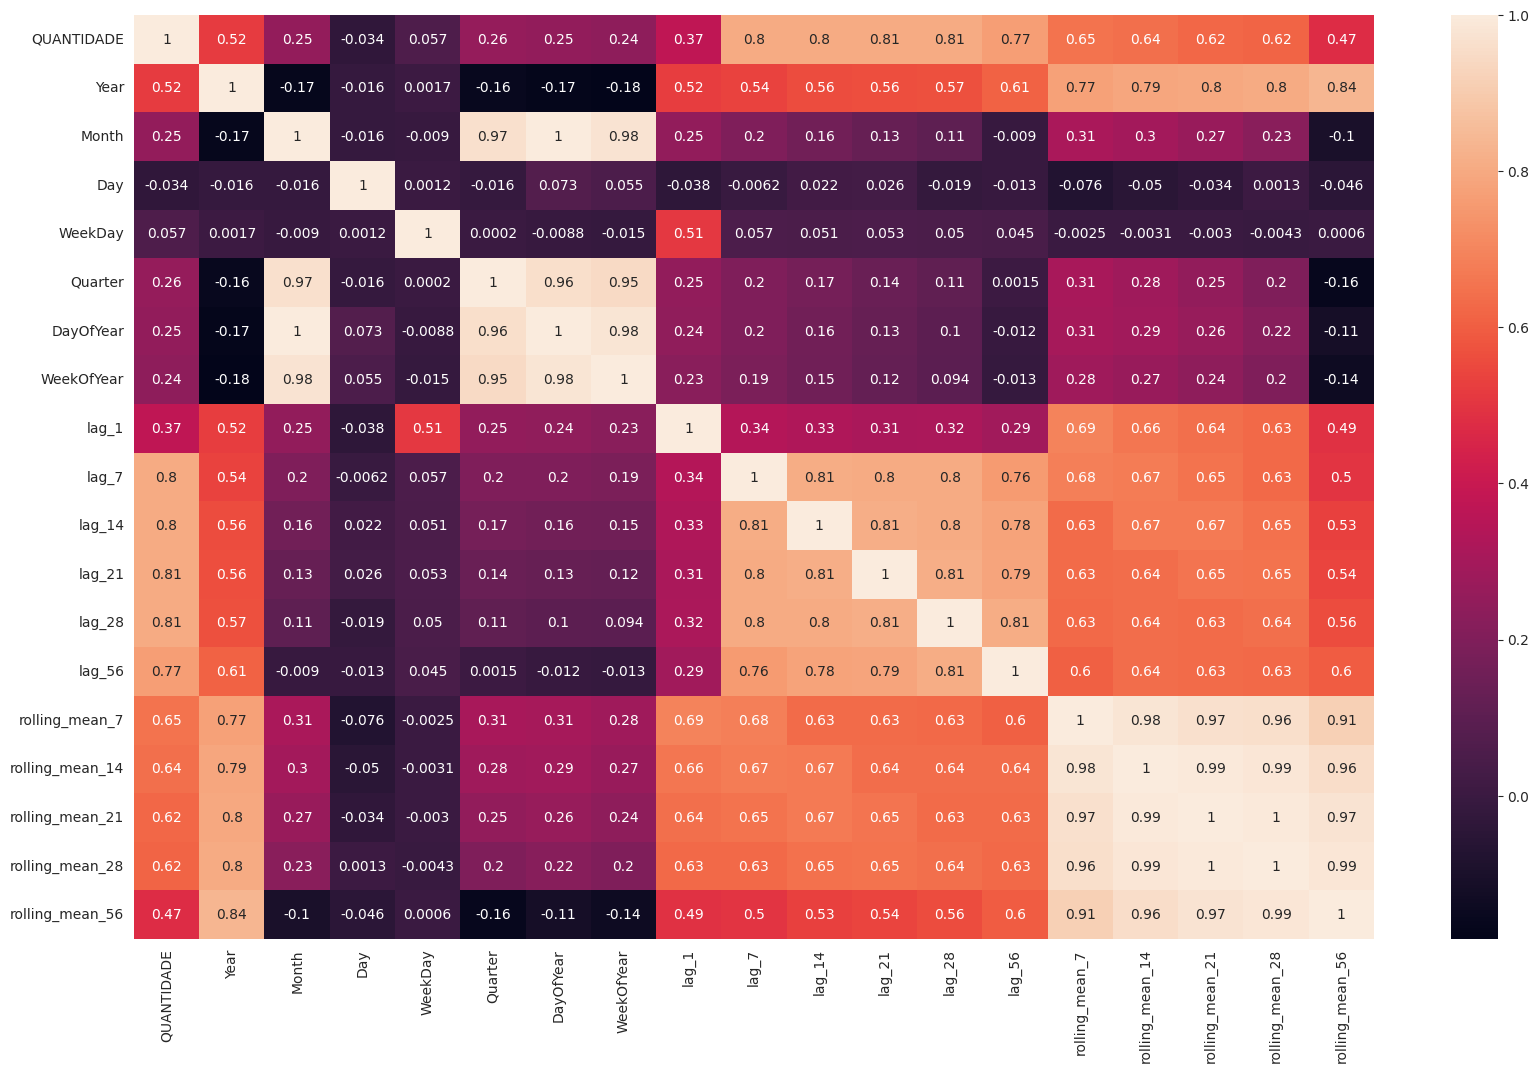

In [ ]:
#Correlation Heatmap

df_featured = criaFeaturesCorrelatas(criaFeaturesTemporais(historico_adultos))

plt.figure(figsize=(20,12))
corr = df_featured.corr()
sns.heatmap(corr, annot=True)
plt.show()

Podemos ver uma alta correlação entre os lags 7,14,21 e 28. Isso significa que a demanda da semana anterior explica muito bem a da semana atual.
A forte correlação com o Lag 56 também denota um forte padrão bimestral nas vendas.
A média movél (rolling mean) também explica bem a demanda, principalmente a Média movel dos ultimos 7 dias (rolling_mean_7), que é um bom preditor a curto prazo.


---

# Modelagem

Para modelagem, vou utilizar os 2 modelos: SARIMAX e Prophet. Esses serão escolhidos pelo padrão sazonal dos dados. Separei a base de treino e teste respeitando a váriavel temporal. Assim os últimos 180 dias (6 meses em frequência diária) foram utilizados como base de treino.

Observações:

A forma como o split foi realizado aloca poucos dados para o treinamento, o que pode comprometer a performance do modelo e levar ao overfit nos dados disponíveis. Além disso, nesse split não foi feita a separação de uma base de validação, e as métricas foram obtidas diretamente utilizando a base de testes. Embora essa abordagem não seja a ideal, ela se faz necessária devido à quantidade limitada de dados e ao grande horizonte temporal da previsão.

In [ ]:
fim_treino = adultos_diario.index.max()-pd.Timedelta(unit = 'D', value = 180)

In [ ]:
df_train = adultos_diario[:fim_treino]
df_test = adultos_diario[fim_treino+pd.Timedelta(unit = 'D', value = 1):]

In [ ]:
# tamanho da divisão:
print("Tamanho do conjunto de treino: ", df_train.shape)
print("Tamanho do conjunto de teste:  ", df_test.shape)
# visualização do set de treino
df_train.head()

Tamanho do conjunto de treino:  (483, 1)
Tamanho do conjunto de teste:   (180, 1)


,QUANTIDADE
DATA_VENDA,
2020-01-02,3340.0
2020-01-03,3420.0
2020-01-04,4010.0
2020-01-05,2605.0
2020-01-06,3461.0


In [136]:
def calculo_erro(previsto, real):

    erro = previsto - real
    total_y = 0
    ape = 0
    for y, p in zip(real, previsto):
        if y > 0:
            ape += abs((y - p)/y)
            total_y += 1

    mape = ape/total_y

    resultados = {'MAPE': mape, 'MAE': np.mean(np.abs(erro))}

    print("=" * 30)
    print(f"{'MÉTRICAS DE ERRO':^30}")
    print("=" * 30)
    print(f"  MAPE: {mape:.2%}")
    print(f"  MAE:  {resultados['MAE']:,.2f}")
    print("=" * 30)

    return resultados

In [ ]:
metricas = {}

## Sarimax

In [ ]:
df_m = df_train.copy()
df_mt = df_test.copy()

In [ ]:
fourier_feat = FourierFeaturizer(m = 96, k = 5)
exog_train_sarimax  = fourier_feat.fit_transform(df_m)[1]
exog_train_sarimax.index = df_m.index

In [ ]:
model = auto_arima(y = df_m,
                  X = exog_train_sarimax,
                  method = 'nm',
                  max_D = 2,
                  stepwise = True,
                  maxiter = 50,
                  trace = True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8481.724, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8281.526, Time=0.42 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8090.634, Time=0.52 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7921.704, Time=0.90 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8293.808, Time=0.45 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7948.521, Time=0.81 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7913.887, Time=0.95 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8384.121, Time=1.02 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=8287.489, Time=2.09 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=7922.139, Time=2.54 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=7909.186, Time=1.73 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=7915.332, Time=0.78 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=8348.731, Time=0.92 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=8285.424, Time=1.26 sec
 ARIMA(1,1,1)(0,0,0)[0]          

In [104]:
model = sm.tsa.statespace.SARIMAX(endog = df_m,
                                  order=(0,1,2),
                                  exog = exog_train_sarimax,
                                  freq='D')
res = model.fit()

In [107]:
exog_test_sarimax = fourier_feat.transform(X = df_mt, n_periods=df_mt.shape[0])[1]
exog_test_sarimax.index = df_mt.index

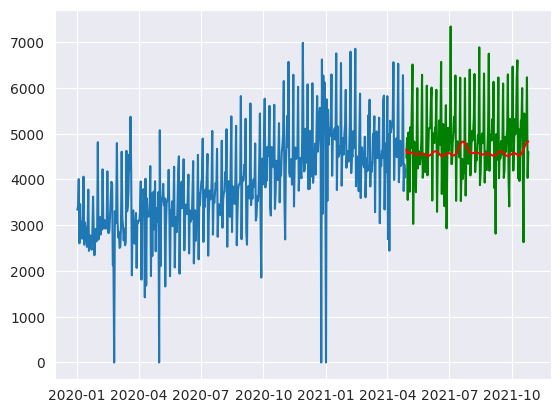

In [120]:
# Gerando as previsões
y_predict = res.predict(start=df_mt.index.min(), end=df_mt.index.max(), exog=exog_test_sarimax)
#plot dos resultados
plt.plot(df_m.QUANTIDADE)
plt.plot(df_mt.QUANTIDADE, color='green')
plt.plot(y_predict,color= 'red')

In [121]:
# The line below created a self-referential series, causing a recursion error.
# y_predict['pred'] = y_predict
# y_predict is already a pandas Series with the predictions.

In [137]:
calculo_erro(y_predict, df_mt.QUANTIDADE)

       MÉTRICAS DE ERRO       
  MAPE: 13.17%
  MAE:  638.10


{'MAPE': 0.13171815170828166, 'MAE': np.float64(638.1029305062046)}

In [125]:
# ajuste do dataset de treino e teste
train_prophet = df_train[['QUANTIDADE']].reset_index()
train_prophet.columns = ['ds', 'y']
test_prophet = df_test[['QUANTIDADE']].reset_index()
test_prophet.columns = ['ds', 'y']
train_prophet.head()

,ds,y
0,2020-01-02,3340.0
1,2020-01-03,3420.0
2,2020-01-04,4010.0
3,2020-01-05,2605.0
4,2020-01-06,3461.0


In [126]:
# instancia prophet e treina
m = Prophet(yearly_seasonality = True)
m.add_country_holidays(country_name='BR')
m.fit(train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


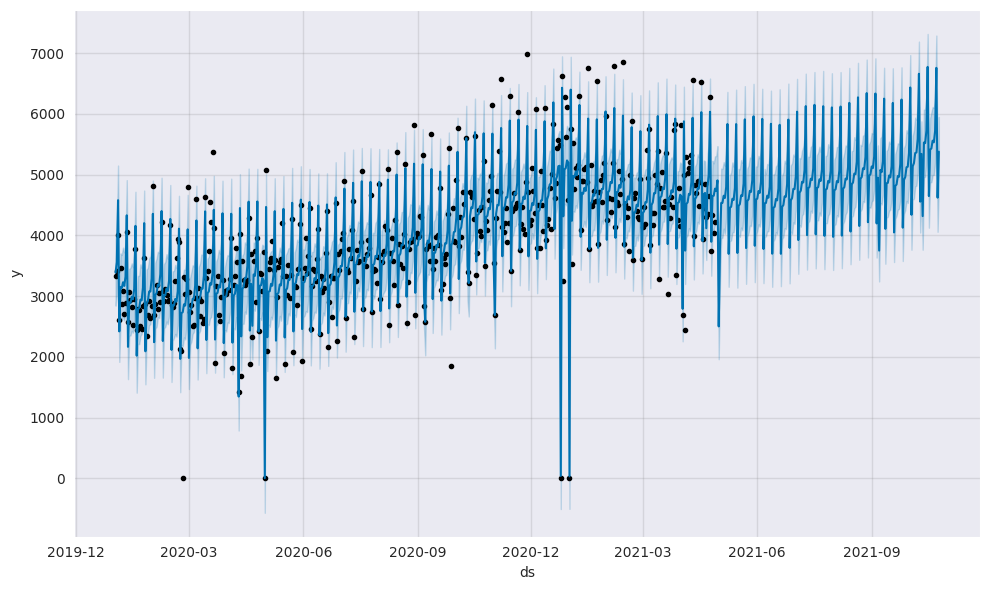

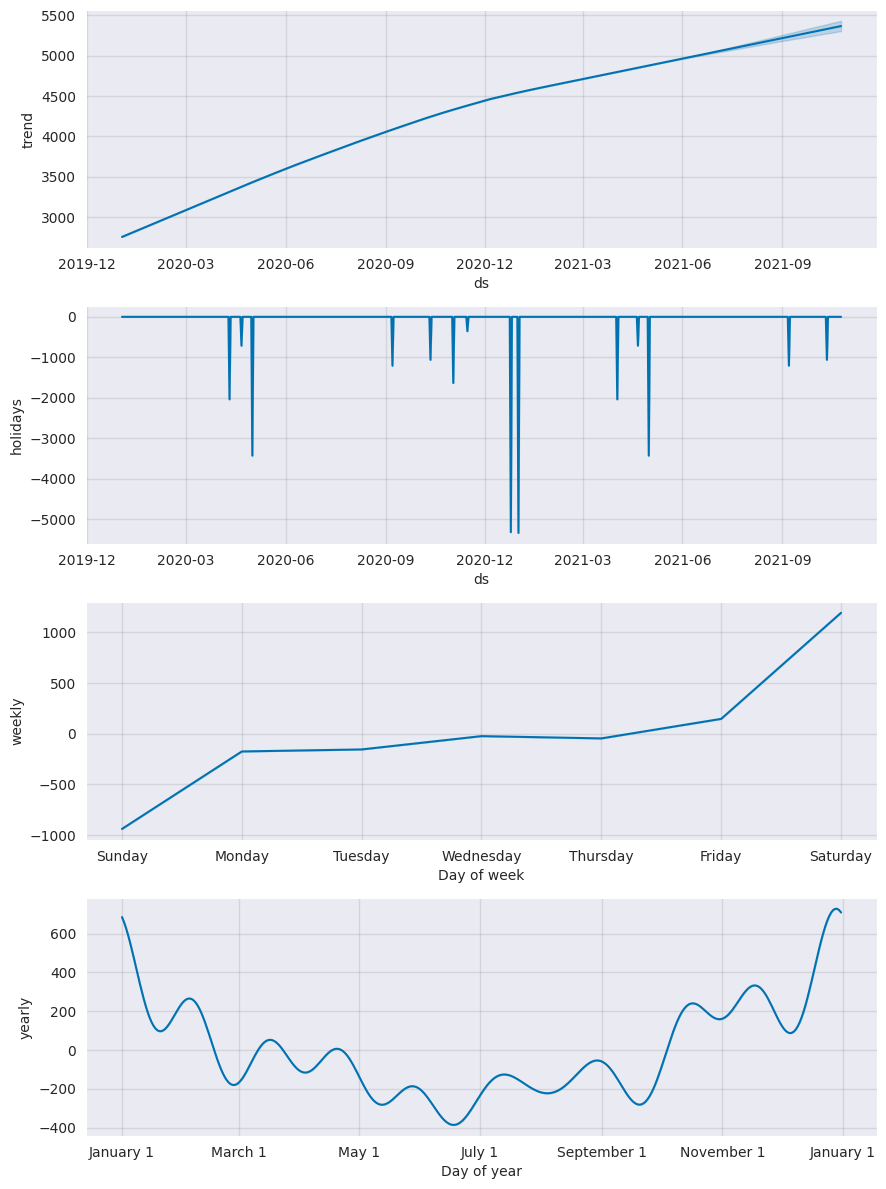

In [127]:
# construção do dataset de teste para alimentar o modelo
future = m.make_future_dataframe(periods=len(df_test))

# realiza previsão
forecast = m.predict(future)

#plota previsão
m.plot(forecast);

#plota componentes
m.plot_components(forecast);

In [128]:
prophet_ds = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(test_prophet.set_index('ds'))

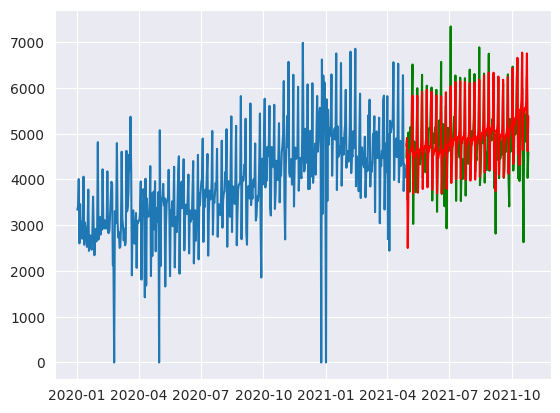

In [129]:
# plot dos resultados
plt.plot(df_train.QUANTIDADE)
plt.plot(df_test.QUANTIDADE, color='green')
plt.plot(prophet_ds['yhat'].tail(180), color='red')

In [130]:
prophet_pred_real = prophet_ds[~prophet_ds.y.isna()]

In [139]:
calculo_erro(prophet_pred_real.yhat, prophet_pred_real.y)

       MÉTRICAS DE ERRO       
  MAPE: 8.33%
  MAE:  365.84


{'MAPE': 0.08327104908565329, 'MAE': np.float64(365.84410740823085)}

## Resultado

O modelo que melhor performou foi o Prophet: MAPE: 8.33% e MAE: 365,84

---

# Deploy
Agora, vamos utilizar o modelo para ser utilizado durante a produção (dia a dia)


In [142]:
import pickle
from prophet import Prophet
from datetime import datetime

# ── Configurações ──────────────────────────────────────
MODEL_PATH   = "prophet_farmasaude.pkl"
HORIZON_DAYS = 180  # ~6 meses

# ── Retreino ───────────────────────────────────────────
def retreinar_modelo(df):
    """df deve ter colunas 'ds' e 'y' — já no formato do seu notebook"""
    print(f"[{datetime.now():%Y-%m-%d %H:%M:%S}] Iniciando retreino...")
    print(f"  Período: {df['ds'].min().date()} → {df['ds'].max().date()}")

    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, seasonality_mode="additive")
    m.add_country_holidays(country_name="BR")
    m.fit(df)

    with open(MODEL_PATH, "wb") as f:
        pickle.dump(m, f)

    print(f"  Modelo salvo em: {MODEL_PATH}")
    return m

# ── Previsão ───────────────────────────────────────────
def prever(model, horizon_days=HORIZON_DAYS):
    print(f"\n[{datetime.now():%Y-%m-%d %H:%M:%S}] Gerando previsão para {horizon_days} dias...")

    future   = model.make_future_dataframe(periods=horizon_days, freq="D")
    forecast = model.predict(future)

    resultado = (
        forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
        .tail(horizon_days)
        .rename(columns={"ds": "Data", "yhat": "Previsao",
                         "yhat_lower": "Limite_Inferior", "yhat_upper": "Limite_Superior"})
        .reset_index(drop=True)
    )

    for col in ["Previsao", "Limite_Inferior", "Limite_Superior"]:
        resultado[col] = resultado[col].clip(lower=0).round(0).astype(int)

    print(f"  Horizonte: {resultado['Data'].min().date()} → {resultado['Data'].max().date()}")
    print(f"  Média diária: {resultado['Previsao'].mean():,.0f} unidades")
    print(f"  Total no período: {resultado['Previsao'].sum():,.0f} unidades")

    return resultado

# ── Execução ───────────────────────────────────────────
# train_prophet já existe no seu notebook com colunas 'ds' e 'y'
model     = retreinar_modelo(train_prophet)
resultado = prever(model)
resultado.head()

[2026-03-08 17:37:40] Iniciando retreino...
  Período: 2020-01-02 → 2021-04-28
  Modelo salvo em: prophet_farmasaude.pkl

[2026-03-08 17:37:41] Gerando previsão para 180 dias...
  Horizonte: 2021-04-29 → 2021-10-25
  Média diária: 4,931 unidades
  Total no período: 887,550 unidades


,Data,Previsao,Limite_Inferior,Limite_Superior
0,2021-04-29,4731,4196,5311
1,2021-04-30,4906,4314,5427
2,2021-05-01,2503,1947,3012
3,2021-05-02,3787,3246,4354
4,2021-05-03,4533,3975,5126
